# Model Explainability

In credit scoring you can't just say "the model said no" — regulators (and customers) want to know *why*. SHAP gives us that.

In [2]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import roc_auc_score
from src.data_loader import load_raw_data, get_feature_target
from src.preprocessing import split_data, impute_missing, scale_features
from src.feature_engineering import create_interaction_features
from src.config import CONFIG

sns.set_theme(style='whitegrid')
%matplotlib inline

In [3]:
df = load_raw_data()
X, y = get_feature_target(df)
X_train, X_test, y_train, y_test = split_data(X, y)
X_train, X_test, imputer = impute_missing(X_train, X_test)
X_train_full = create_interaction_features(X_train)
X_test_full = create_interaction_features(X_test)
X_train_sc, X_test_sc, scaler = scale_features(X_train_full, X_test_full)

# load tree models
tree_models = {}
for name in ['random_forest', 'xgboost', 'lightgbm']:
    tree_models[name] = joblib.load(f'../data/processed/model_{name}.joblib')

# pick best one
best_name = max(tree_models,
    key=lambda k: roc_auc_score(y_test, tree_models[k].predict_proba(X_test_full)[:, 1]))
best_tree = tree_models[best_name]
lr_model = joblib.load('../data/processed/model_logistic_regression.joblib')
print(f"Using {best_name} for SHAP analysis")

Using random_forest for SHAP analysis


## SHAP values

In [4]:
explainer = shap.TreeExplainer(best_tree)
shap_values = explainer.shap_values(X_test_full)

# binary classifiers: list of arrays (old SHAP) or 3D array (new SHAP)
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
elif hasattr(shap_values, 'ndim') and shap_values.ndim == 3:
    shap_vals = shap_values[:, :, 1]
else:
    shap_vals = shap_values

print(f"shap_vals shape: {shap_vals.shape}")  # should be (n_samples, n_features)

shap_vals shape: (600, 34)


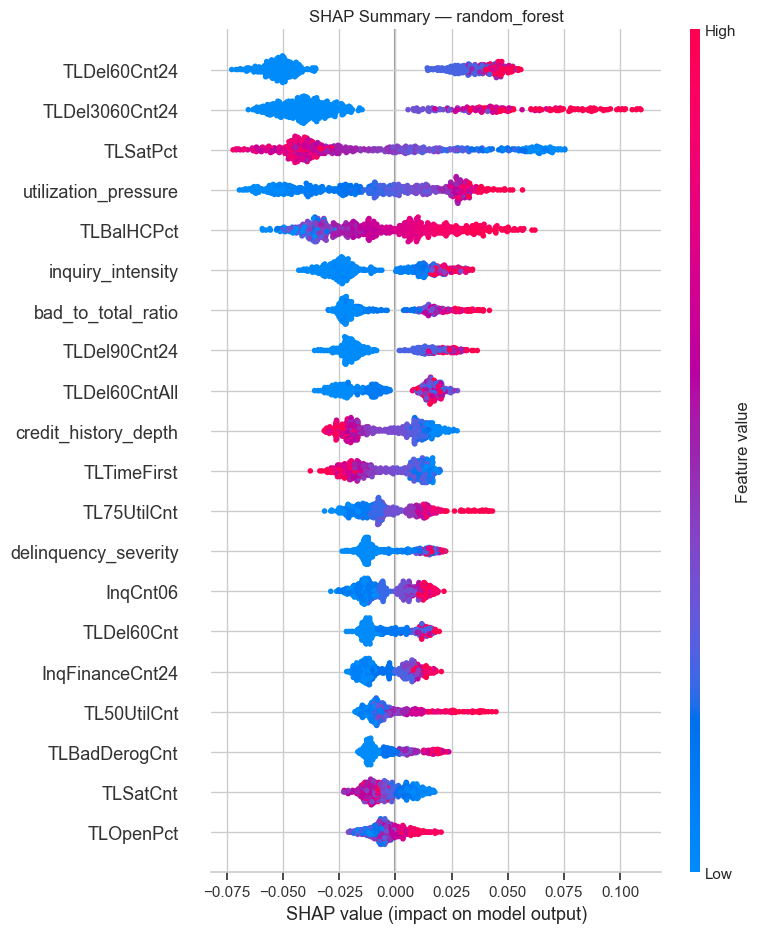

In [5]:
# beeswarm — shows importance AND direction
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_vals, X_test_full, show=False, max_display=20)
plt.title(f'SHAP Summary — {best_name}')
plt.tight_layout()
plt.savefig('../reports/figures/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

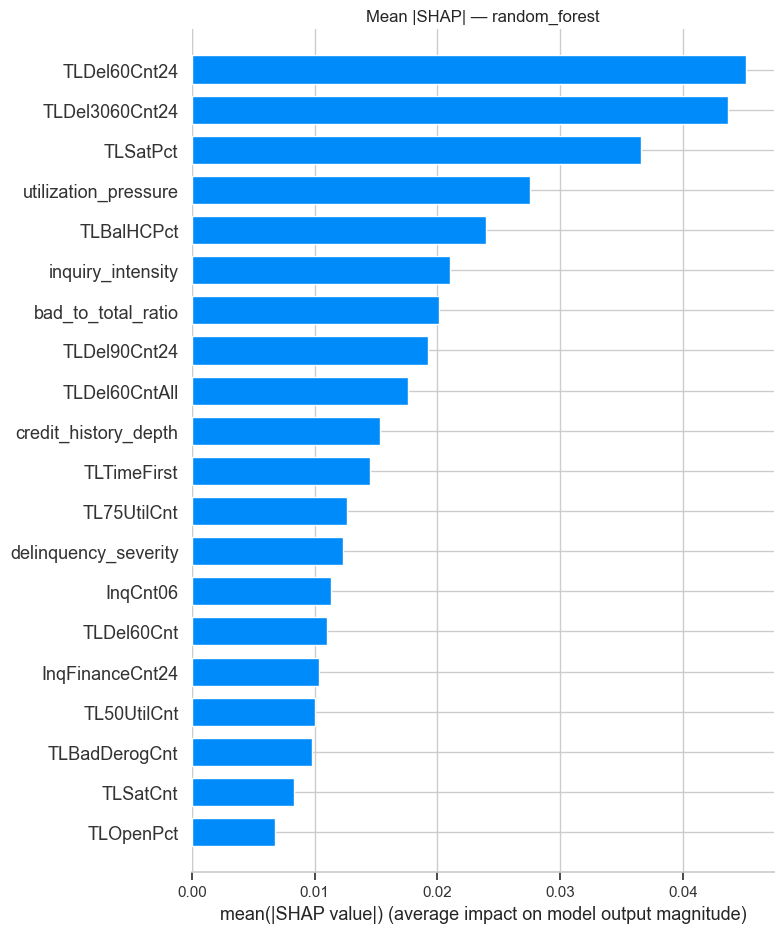

In [6]:
# bar chart version
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals, X_test_full, plot_type='bar', show=False, max_display=20)
plt.title(f'Mean |SHAP| — {best_name}')
plt.tight_layout()
plt.savefig('../reports/figures/shap_importance_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## Dependence plots for top features

How does each feature's value affect the prediction?

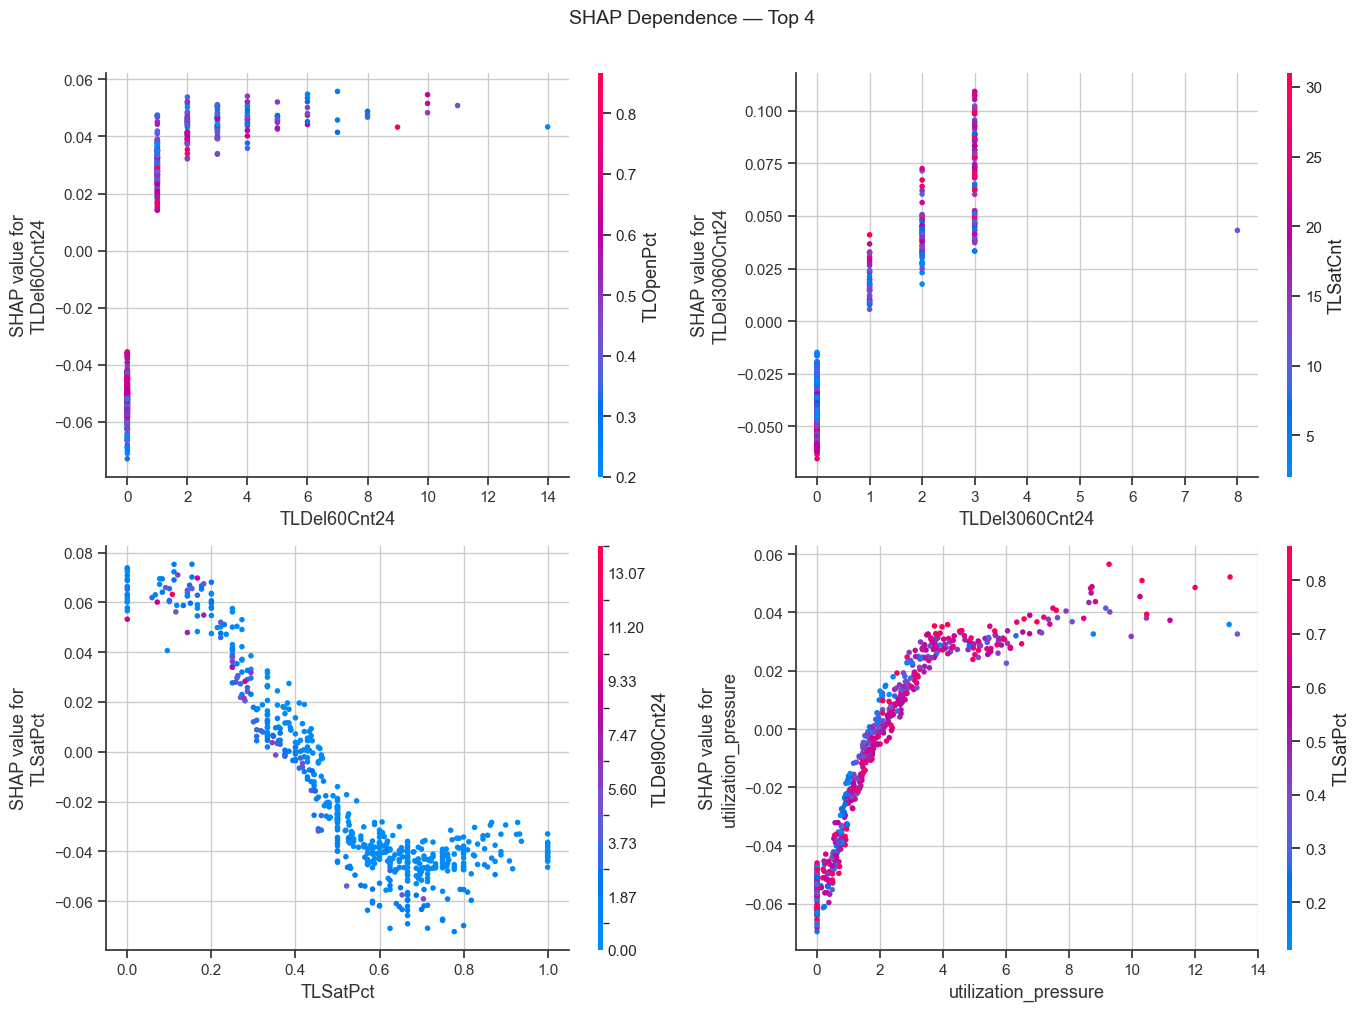

In [7]:
mean_shap = np.abs(shap_vals).mean(axis=0)
if mean_shap.ndim > 1:
    mean_shap = mean_shap[:, 1]

cols = list(X_test_full.columns)
top4 = [cols[i] for i in np.argsort(mean_shap)[::-1][:4]]

# ensure shap_vals is 2D and features is plain numpy (SHAP chokes on PyArrow-backed DataFrames)
sv = shap_vals[:, :, 1] if shap_vals.ndim == 3 else shap_vals
X_np = X_test_full.to_numpy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, feat in enumerate(top4):
    shap.dependence_plot(feat, sv, X_np, feature_names=cols, ax=axes.flatten()[i], show=False)

plt.suptitle('SHAP Dependence — Top 4', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/shap_dependence_plots.png', dpi=150, bbox_inches='tight')
plt.show()

## Individual predictions

Let's explain 3 specific applicants — one clearly good, one bad, one on the edge.

In [ ]:
probs = best_tree.predict_proba(X_test_full)[:, 1]

idx_good = np.argmin(probs)
idx_bad = np.argmax(probs)
idx_border = np.argmin(np.abs(probs - 0.3))  # borderline

cases = [
    (idx_good, 'Low Risk'),
    (idx_border, 'Borderline'),
    (idx_bad, 'High Risk'),
]

for idx, label in cases:
    print(f"\n--- {label} ---")
    print(f"P(default) = {probs[idx]:.3f}, Actual = {'Bad' if y_test.iloc[idx]==1 else 'Good'}")
    
    plt.figure(figsize=(12, 4))
    ev = explainer.expected_value
    base_val = float(ev[1]) if isinstance(ev, (list, np.ndarray)) and np.asarray(ev).ndim > 0 and len(ev) > 1 else float(ev)
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_vals[idx], base_values=base_val,
            data=X_test_full.iloc[idx],
            feature_names=X_test_full.columns.tolist()
        ),
        max_display=10, show=False
    )
    plt.title(f'{label} Applicant')
    plt.tight_layout()
    plt.show()

## Logistic regression coefficients

These are directly interpretable since the features were scaled.

In [ ]:
coef_df = pd.DataFrame({
    'Feature': X_train_full.columns,
    'Coef': lr_model.coef_[0]
}).sort_values('Coef')

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in coef_df['Coef']]
ax.barh(coef_df['Feature'], coef_df['Coef'], color=colors, edgecolor='black', linewidth=0.3)
ax.set_xlabel('Coefficient (+ = riskier)')
ax.set_title('Logistic Regression Coefficients')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('../reports/figures/lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

## Partial dependence plots

In [ ]:
top4_idx = [list(X_test_full.columns).index(f) for f in top4]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
PartialDependenceDisplay.from_estimator(
    best_tree, X_test_full, features=top4_idx,
    kind='both', subsample=100, ax=axes,
    random_state=CONFIG['random_state'],
    ice_lines_kw={'color': 'tab:blue', 'alpha': 0.1, 'linewidth': 0.5},
    pd_line_kw={'color': 'red', 'linewidth': 2}
)
plt.suptitle(f'Partial Dependence — {best_name}', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/partial_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

The SHAP results and the logistic regression coefficients largely agree on the top risk drivers, which is a good sign. The tree models capture non-linear effects that the LR misses though (visible in the dependence plots).